# TRABAJO PRÁCTICO DE CLUSTERING: CONSIGNAS

# ALUMNO: Moises Lobayza

# Importamos librerias necesarias antes de empezar a trábajar:

In [37]:
# Librerías principales
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Modelos de clustering
from sklearn.cluster import KMeans, DBSCAN

# Métricas y reducción de dimensionalidad
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

## Utilizando solo Numpy y Scikit-learn, y opcionalmente Pandas y Matplotlib, debes realizar  lo siguiente sobre el conjunto de datos de California Housing:

## 1. Analiza los datos, inspecciona todas las características y el target.

**Explica de que trata el dataset, cada una de sus variables**

**Asegúrate de preparar los datos para utilizarse en modelos  predictivos.**

**Puedes hacer el preprocesamiento de características  (selección, transformación) que consideres más adecuado, justificar.**

Fuente del dataset: https://www.kaggle.com/datasets/camnugent/california-housing-prices



In [38]:

# Descarga la última versión del dataset
path = kagglehub.dataset_download("camnugent/california-housing-prices")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'california-housing-prices' dataset.
Path to dataset files: /kaggle/input/california-housing-prices


In [39]:
! ls /kaggle/input/california-housing-prices/*

/kaggle/input/california-housing-prices/housing.csv


In [40]:
files_in_path = os.listdir(path)
print(f"Archivos en el directorio {path}: {files_in_path}")
ruta_al_archivo = path + "/" +files_in_path[0]

print(f"Cargando datos desde : {ruta_al_archivo}")
df = pd.read_csv(ruta_al_archivo)
print("DataFrame 'df' creado. Muestro las primeras 5 filas:")
display(df.head())


Archivos en el directorio /kaggle/input/california-housing-prices: ['housing.csv']
Cargando datos desde : /kaggle/input/california-housing-prices/housing.csv
DataFrame 'df' creado. Muestro las primeras 5 filas:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# 1. Análisis inicial del dataset

El dataset utilizado es California Housing Prices, que contiene información demográfica, geográfica y habitacional de distintos distritos de California.

El objetivo general del dataset es analizar características asociadas a viviendas y población en distintas zonas. La variable objetivo o target es `median_house_value`, que representa el valor medio de las viviendas en cada distrito.

**Aunque en este trabajo se aplicarán modelos de clustering, el target se analizará para comprender los datos, pero no se utilizará directamente como variable de entrada para formar los clusters.**

In [41]:
print("Cantidad de filas y columnas:", df.shape)
df.head()

Cantidad de filas y columnas: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [42]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [43]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Descripción de las variables

- `longitude`: longitud geográfica del distrito.
- `latitude`: latitud geográfica del distrito.
- `housing_median_age`: antigüedad media de las viviendas del distrito.
- `total_rooms`: cantidad total de habitaciones.
- `total_bedrooms`: cantidad total de dormitorios.
- `population`: población total del distrito.
- `households`: cantidad total de hogares.
- `median_income`: ingreso medio de los hogares.
- `median_house_value`: valor medio de las viviendas. Es la variable objetivo.
- `ocean_proximity`: cercanía del distrito al océano. Es una variable categórica.

El dataset combina variables numéricas y una variable categórica. Por eso, antes de aplicar modelos de clustering será necesario preparar los datos mediante imputación de valores faltantes, escalado de variables numéricas y codificación de la variable categórica.

In [44]:
# Valores faltantes por columna
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [45]:
# Cantidad de valores únicos por columna
df.nunique()

,0
longitude,844
latitude,862
housing_median_age,52
total_rooms,5926
total_bedrooms,1923
population,3888
households,1815
median_income,12928
median_house_value,3842
ocean_proximity,5


In [46]:
# Distribución de la variable categórica ocean_proximity
df["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [47]:
# Distribución del target
df["median_house_value"].describe()

,median_house_value
count,20640.000000
mean,206855.816909
std,115395.615874
min,14999.000000
25%,119600.000000
50%,179700.000000
75%,264725.000000
max,500001.000000


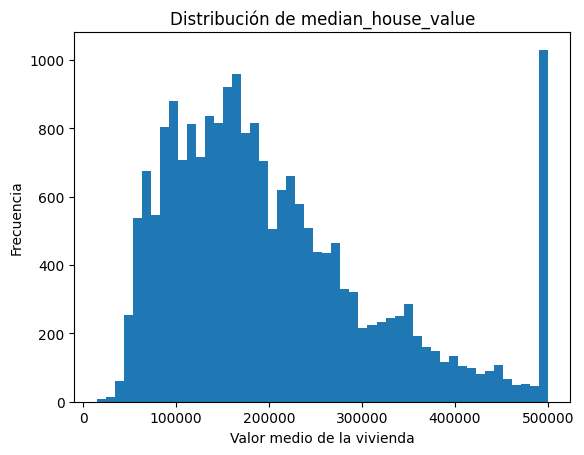

In [48]:

plt.hist(df["median_house_value"], bins=50)
plt.xlabel("Valor medio de la vivienda")
plt.ylabel("Frecuencia")
plt.title("Distribución de median_house_value")
plt.show()

La variable `median_house_value` presenta una distribución asimétrica hacia la derecha. La mayor parte de las viviendas se concentra aproximadamente entre 100.000 y 250.000 dólares.

También se observa un pico muy marcado cerca de 500.000, lo que indica que el dataset tiene un valor máximo recortado o limitado. Es decir, muchas viviendas cuyo valor real podría ser superior aparecen registradas con el mismo valor máximo.

**Por esta razón, `median_house_value` se usará solo para interpretar los clusters y no como variable de entrada en el modelo.**

In [49]:
# Correlación entre variables numéricas
corr = df.corr(numeric_only=True)

corr["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


La variable con mayor correlación positiva con `median_house_value` es `median_income`, con un valor aproximado de 0.69. Esto indica que las zonas con mayores ingresos medios tienden a tener viviendas de mayor valor medio.

El resto de las variables numéricas tienen correlaciones mucho más bajas. `total_rooms`, `housing_median_age`, `households` y `total_bedrooms` presentan relaciones positivas débiles.

Por otro lado, `latitude` y `longitude` tienen correlaciones negativas débiles, pero esto no significa que no sean importantes. Al ser variables geográficas, su relación con el valor de la vivienda puede ser no lineal y depender de la ubicación específica.

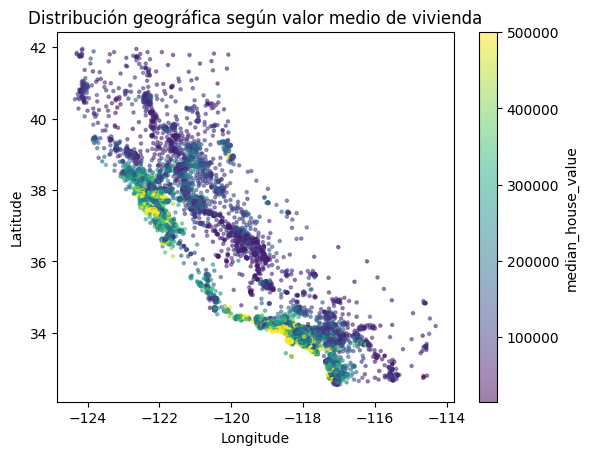

In [50]:
# Visualización geográfica simple
plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["median_house_value"],
    s=5,
    alpha=0.5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribución geográfica según valor medio de vivienda")
plt.colorbar(label="median_house_value")
plt.show()

La visualización geográfica muestra que los puntos siguen una forma similar al estado de California, ya que se grafican las coordenadas de latitud y longitud.

También se observa que los valores más altos de `median_house_value` tienden a concentrarse en zonas costeras, especialmente cerca de grandes áreas urbanas. Esto sugiere que la ubicación geográfica es una característica importante para analizar el valor de las viviendas.

**Aunque `latitude` y `longitude` no tienen una correlación lineal fuerte con el target, visualmente muestran patrones espaciales relevantes. Por eso, se consideran variables útiles para el clustering.**

## Preparación de datos para clustering

Para aplicar modelos de clustering se prepara una matriz de características `X`.

No se utiliza `median_house_value` como variable de entrada porque representa el target del dataset. En este trabajo se usará después para interpretar los grupos obtenidos, pero no para formarlos directamente.

El preprocesamiento elegido es:

1. Imputar los valores faltantes de las variables numéricas usando la mediana.
2. Escalar las variables numéricas con `StandardScaler`, ya que K-Means y DBSCAN son sensibles a las escalas.
3. Codificar la variable categórica `ocean_proximity` mediante One Hot Encoding.

In [51]:
# Separo target y características
target = "median_house_value"

X = df.drop(columns=[target])
y = df[target]

# Variables numéricas y categóricas
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Variables numéricas:", list(numeric_features))
print("Variables categóricas:", list(categorical_features))

Variables numéricas: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Variables categóricas: ['ocean_proximity']


In [53]:
# Transformador para variables numéricas
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Transformador para variables categóricas
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocesamiento completo
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Aplicamos el preprocesamiento
X_processed = preprocessor.fit_transform(X)

print("Datos originales:", X.shape)
print("Datos preprocesados:", X_processed.shape)

Datos originales: (20640, 9)
Datos preprocesados: (20640, 13)


Con este preprocesamiento, los datos quedan listos para aplicar modelos de clustering.

Se decidió excluir `median_house_value` del entrenamiento para evitar que los clusters se formen directamente a partir del valor de las viviendas. De esta manera, los grupos se generan usando características geográficas, demográficas y habitacionales, y luego el target puede utilizarse para interpretar los resultados.

## 2. Realiza un clustering sobre los datos con K-means, separándolos en un número manejable de  grupos (de 2 a 10).

2.1) Justifica cuál métrica ( o grupo de métricas) utilizas para determinar el valor de k.

2.2) Realiza un análisis descriptivo de cada clúster, grafica para cada uno diagrama cajas.

# 2. Aplicación de K-Means

En esta segunda parte se aplica el algoritmo K-Means para agrupar los distritos del dataset según sus características geográficas, demográficas y habitacionales.

Como K-Means requiere definir previamente la cantidad de clusters, se probarán distintos valores de `k` entre 2 y 10.

Para elegir un valor adecuado de `k`, se utilizarán las siguientes métricas:

- **Inercia**: mide qué tan compactos son los clusters. Se analiza con el método del codo.
- **Silhouette Score**: mide qué tan bien separado está cada punto respecto de otros clusters. Valores más altos indican mejores agrupamientos.
- **Davies-Bouldin Score**: mide la separación y compactación de los clusters. Valores más bajos indican mejores resultados.

In [54]:
k_values = range(2, 11)

inertias = []
silhouette_scores = []
davies_bouldin_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_processed)

    inertias.append(kmeans.inertia_)

    # Se usa una muestra para que el cálculo sea más rápido
    silhouette = silhouette_score(
        X_processed,
        labels,
        sample_size=5000,
        random_state=42
    )

    davies = davies_bouldin_score(X_processed, labels)

    silhouette_scores.append(silhouette)
    davies_bouldin_scores.append(davies)

# Tabla de resultados

In [55]:
resultados_kmeans = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores,
    "davies_bouldin_score": davies_bouldin_scores
})

resultados_kmeans

,k,inertia,silhouette_score,davies_bouldin_score
0,2,135321.583327,0.402178,1.175569
1,3,101808.105262,0.295667,1.251872
2,4,88984.406717,0.290264,1.184257
3,5,81800.374948,0.254665,1.359684
4,6,74456.419684,0.232691,1.405623
5,7,68243.380253,0.220881,1.389277
6,8,63740.606970,0.226349,1.343323
7,9,60112.426821,0.211136,1.390918
8,10,57301.443720,0.214272,1.347989


# Gráfico del método del codo

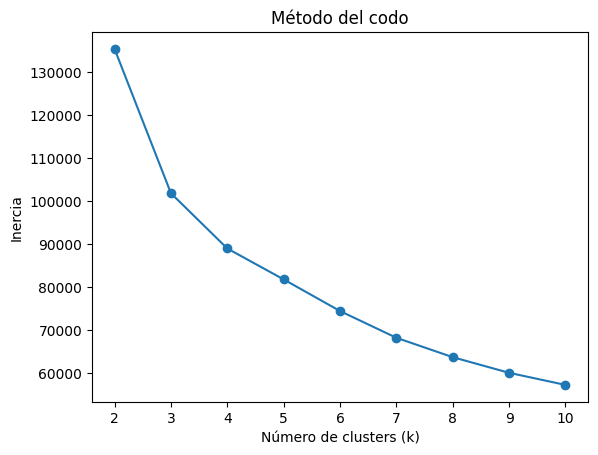

In [56]:
plt.plot(resultados_kmeans["k"], resultados_kmeans["inertia"], marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.xticks(list(k_values))
plt.show()

# Gráfico de Silhouette Score

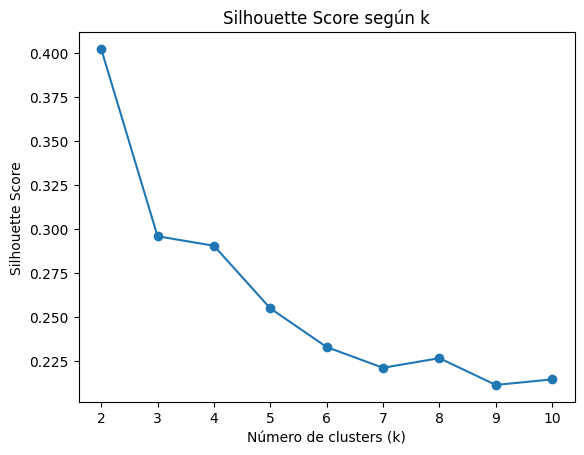

In [57]:
plt.plot(resultados_kmeans["k"], resultados_kmeans["silhouette_score"], marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score según k")
plt.xticks(list(k_values))
plt.show()

# Gráfico de Davies-Bouldin Score

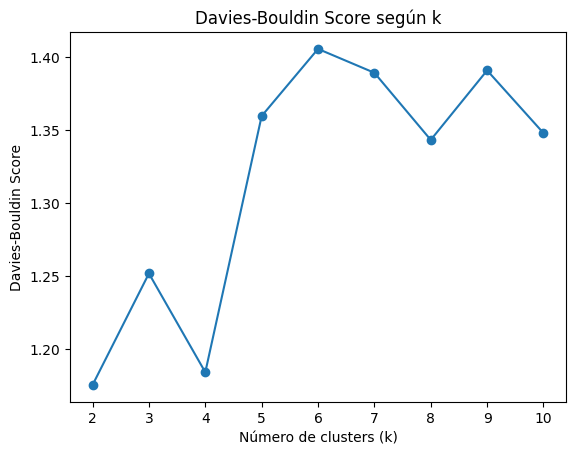

In [58]:
plt.plot(resultados_kmeans["k"], resultados_kmeans["davies_bouldin_score"], marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Davies-Bouldin Score")
plt.title("Davies-Bouldin Score según k")
plt.xticks(list(k_values))
plt.show()

# Interpretación

Aunque las métricas Silhouette Score y Davies-Bouldin Score muestran mejores resultados para `k = 2`, se selecciona `k = 4` como valor final porque permite obtener una segmentación más detallada del dataset.

El método del codo muestra una disminución importante de la inercia hasta aproximadamente `k = 4`, y el Davies-Bouldin Score presenta una mejora respecto de `k = 3`.

Por lo tanto, `k = 4` representa un equilibrio entre calidad del agrupamiento e interpretabilidad de los clusters.

# Entrenemos el modelo final con k = 4

In [63]:
k_optimo = 4

kmeans_final = KMeans(
    n_clusters=k_optimo,
    random_state=42,
    n_init=10
)

df["cluster_kmeans"] = kmeans_final.fit_predict(X_processed)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,cluster_kmeans
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,1
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,2
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,1
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,1
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,1


# Analizemos e interpretamos cada cluster.

**Se observa la cantidad de distritos asignados a cada cluster. Esto permite ver si los grupos quedaron relativamente equilibrados o si alguno concentra muchos más registros que otros.**

In [64]:
df["cluster_kmeans"].value_counts().sort_index()

,count
cluster_kmeans,
0,9624
1,7816
2,2891
3,309


**Promedio de variables numéricas por cluster.**

In [65]:
df.groupby("cluster_kmeans").mean(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
cluster_kmeans,,,,,,,,,
0,-118.002999,33.897556,30.802681,1957.500416,409.043478,1155.135806,385.472672,3.906340,214442.270158
1,-121.677422,37.953974,30.260107,2047.018808,407.253359,1038.055271,378.274181,3.729300,192332.473900
2,-119.159395,35.183729,18.818056,5291.482186,1093.544184,2797.689035,1005.293670,4.077468,220166.042546
3,-118.890939,35.103948,12.161812,13805.799353,2637.788961,6806.647249,2387.750809,4.400849,213401.320388


**Ahora vemos qué proporción de cada cluster está cerca del océano.**

In [66]:
pd.crosstab(df["cluster_kmeans"], df["ocean_proximity"], normalize="index")

ocean_proximity,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
cluster_kmeans,,,,,
0,0.652743,0.188383,0.00052,0.000000,0.158354
1,0.167221,0.470957,0.00000,0.264713,0.097108
2,0.492909,0.316845,0.00000,0.069180,0.121065
3,0.394822,0.456311,0.00000,0.067961,0.080906


# Boxplots para interpretar clusters

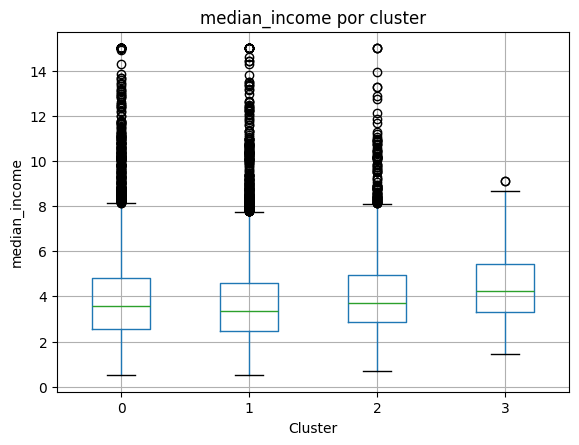

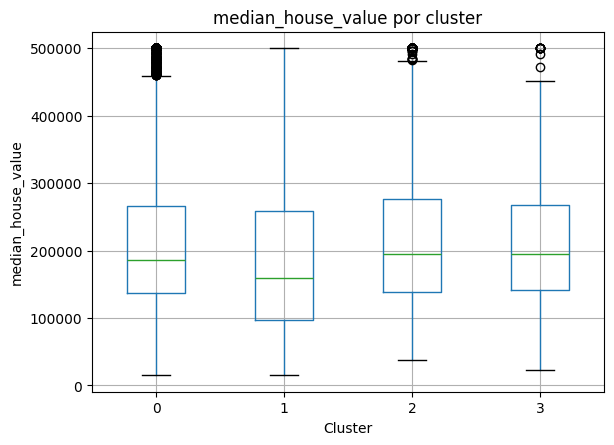

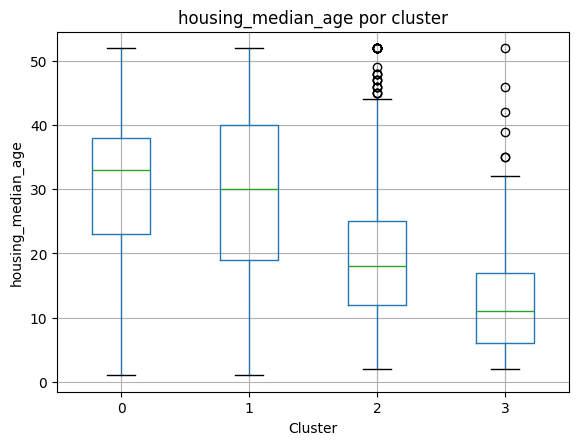

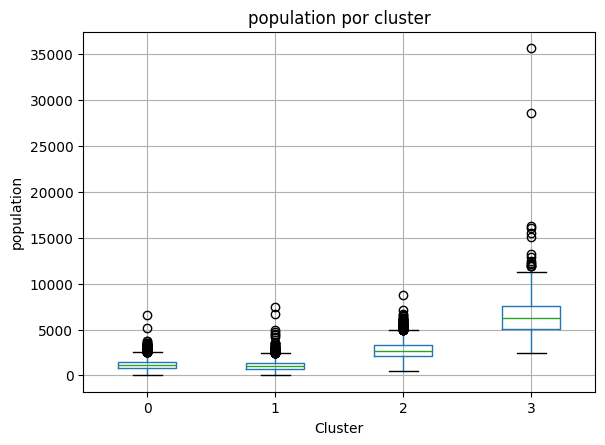

In [67]:
variables = [
    "median_income",
    "median_house_value",
    "housing_median_age",
    "population"
]

for var in variables:
    df.boxplot(column=var, by="cluster_kmeans")
    plt.title(f"{var} por cluster")
    plt.suptitle("")
    plt.xlabel("Cluster")
    plt.ylabel(var)
    plt.show()

# Visualización geográfica de los clusters

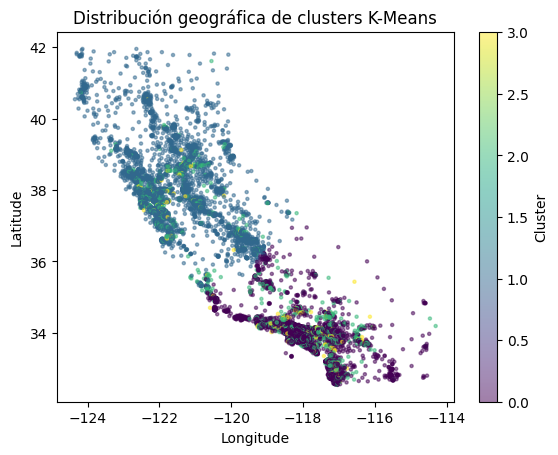

In [68]:
plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["cluster_kmeans"],
    s=5,
    alpha=0.5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribución geográfica de clusters K-Means")
plt.colorbar(label="Cluster")
plt.show()

## Análisis de los clusters obtenidos con K-Means

El modelo K-Means con `k = 4` generó cuatro clusters de tamaños distintos. Los clusters 0 y 1 concentran la mayor parte de los registros, mientras que el cluster 3 es mucho más pequeño, con solo 309 observaciones.

### Cluster 0

Este cluster agrupa principalmente distritos ubicados cerca de la costa, ya que más del 65% de sus registros pertenecen a la categoría `<1H OCEAN`. Presenta un ingreso medio cercano a 3.9 y un valor medio de vivienda de aproximadamente 214.000.

Geográficamente, se concentra principalmente en zonas del sur de California. Puede interpretarse como un grupo de distritos costeros o relativamente cercanos al océano, con valores de vivienda medios-altos.

### Cluster 1

Este cluster tiene una mayor presencia de zonas `INLAND` y `NEAR BAY`. Presenta un ingreso medio algo menor que los demás clusters y también el valor medio de vivienda más bajo, cercano a 192.000.

Puede interpretarse como un grupo de distritos más alejados de las zonas costeras más caras, con menor ingreso medio y menor valor de vivienda.

### Cluster 2

Este grupo tiene distritos con mayor cantidad promedio de habitaciones, dormitorios, población y hogares en comparación con los clusters 0 y 1. Además, presenta viviendas más nuevas, ya que su `housing_median_age` promedio es menor.

También muestra un valor medio de vivienda más alto, cercano a 220.000. Puede interpretarse como un grupo de zonas más grandes, más pobladas y relativamente más nuevas.

### Cluster 3

Este cluster es el más pequeño y se diferencia claramente por tener valores muy altos en `total_rooms`, `total_bedrooms`, `population` y `households`. También tiene el ingreso medio más alto y la menor antigüedad promedio de viviendas.

Sin embargo, su valor medio de vivienda no es el más alto, lo que indica que este grupo parece representar zonas muy grandes, densas o con desarrollos habitacionales recientes, más que zonas necesariamente más caras.

### Interpretación general

Los clusters no se diferencian únicamente por el valor medio de las viviendas, sino también por ubicación geográfica, cercanía al océano, tamaño poblacional, cantidad de habitaciones y antigüedad de las viviendas.

La visualización geográfica confirma que K-Means capturó patrones espaciales importantes. Los grupos se distribuyen siguiendo la forma del estado de California, y algunos clusters se concentran más en zonas costeras o interiores.

En conclusión, K-Means permitió segmentar el dataset en grupos interpretables, aunque el cluster 3 quedó muy pequeño y parece estar influido por valores altos en variables relacionadas con tamaño y población.



## 3. Aplica DB-SCAN sobre el mismo dataset que utilizaste en el punto 2.

Realiza una interpretación de su aplicación y un análisis de los resultados obtenidos.

# 3. Aplicación de DBSCAN

En esta sección se aplica DBSCAN, un algoritmo de clustering basado en densidad.

A diferencia de K-Means, DBSCAN no requiere definir previamente la cantidad de clusters. En cambio, utiliza dos parámetros principales:

- `eps`: distancia máxima para considerar que dos puntos pertenecen a una misma vecindad.
- `min_samples`: cantidad mínima de puntos necesarios para formar una región densa.

DBSCAN también puede detectar puntos como ruido, identificándolos con la etiqueta `-1`.

Como DBSCAN puede ser sensible a la dimensionalidad y al escalado, se trabaja sobre los datos previamente procesados y se aplica PCA a 2 componentes para facilitar la visualización y reducir la complejidad.

In [69]:
# Si X_processed es una matriz sparse, la convertimos a array
X_processed_dense = X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed

# PCA a 2 componentes
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed_dense)

print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
print("Varianza explicada total:", pca.explained_variance_ratio_.sum())

Varianza explicada por cada componente: [0.44984547 0.22860616]
Varianza explicada total: 0.6784516331005435


**Gráfico para orientar el valor de eps**

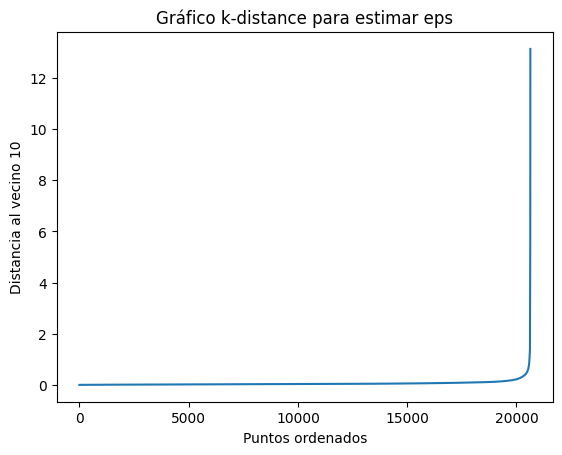

In [70]:
min_samples = 10

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_pca)

distances, indices = neighbors_fit.kneighbors(X_pca)

# Distancia al vecino número min_samples
distances = np.sort(distances[:, -1])

plt.plot(distances)
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al vecino {min_samples}")
plt.title("Gráfico k-distance para estimar eps")
plt.show()

**Probamos varios valores de eps**

In [71]:
eps_values = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.7, 1.0]

resultados_dbscan = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    labels = dbscan.fit_predict(X_pca)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruido = np.sum(labels == -1)
    pct_ruido = n_ruido / len(labels) * 100

    # Silhouette solo si hay al menos 2 clusters y no todos son ruido
    if n_clusters >= 2:
        mask = labels != -1
        sil = silhouette_score(X_pca[mask], labels[mask])
    else:
        sil = np.nan

    resultados_dbscan.append({
        "eps": eps,
        "clusters": n_clusters,
        "ruido": n_ruido,
        "% ruido": pct_ruido,
        "silhouette": sil
    })

resultados_dbscan = pd.DataFrame(resultados_dbscan)
resultados_dbscan

,eps,clusters,ruido,% ruido,silhouette
0,0.10,28,1841,8.919574,-0.509622
1,0.15,7,880,4.263566,-0.135320
2,0.20,9,499,2.417636,-0.031374
3,0.25,3,387,1.875000,0.328904
4,0.30,5,269,1.303295,0.588215
5,0.35,4,191,0.925388,0.683560
6,0.40,4,146,0.707364,0.628451
7,0.50,3,85,0.411822,0.710234
8,0.70,2,49,0.237403,0.758119
9,1.00,3,20,0.096899,0.806520


A partir del gráfico k-distance y de la prueba de distintos valores de `eps`, se observa que valores muy pequeños generan muchos clusters y mayor cantidad de ruido.

A medida que aumenta `eps`, DBSCAN agrupa más puntos y disminuye la cantidad de ruido. Sin embargo, valores demasiado altos pueden unir grupos que deberían permanecer separados.

Se selecciona `eps = 0.5` y `min_samples = 10` porque genera una cantidad razonable de clusters, bajo porcentaje de ruido y un Silhouette Score alto.

**Ahora entrenamos el modelo final:**

In [72]:
eps_optimo = 0.5
min_samples_optimo = 10

dbscan_final = DBSCAN(
    eps=eps_optimo,
    min_samples=min_samples_optimo
)

df["cluster_dbscan"] = dbscan_final.fit_predict(X_pca)

df["cluster_dbscan"].value_counts().sort_index()

,count
cluster_dbscan,
-1,85
0,20530
1,13
2,12


**Gráficamos **

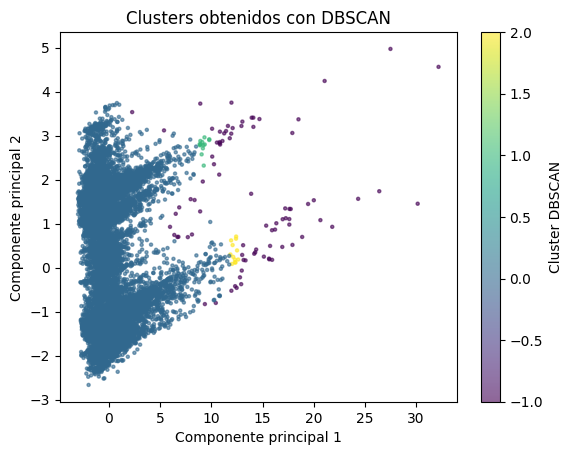

In [73]:
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["cluster_dbscan"],
    s=5,
    alpha=0.6
)

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Clusters obtenidos con DBSCAN")
plt.colorbar(label="Cluster DBSCAN")
plt.show()

**Analizamos los clusters**

In [74]:
df.groupby("cluster_dbscan")[[
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "median_house_value"
]].mean()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
cluster_dbscan,,,,,,,,,
-1,-119.521176,35.708471,9.517647,18590.952941,3432.376471,9124.964706,3145.564706,4.503815,210589.423529
0,-119.569530,35.630763,28.739308,2555.072918,522.982089,1386.514759,486.057720,3.867391,206853.914272
1,-121.639231,38.308462,12.923077,13434.461538,2414.769231,6818.076923,2271.692308,4.232731,158046.153846
2,-117.970000,34.069167,10.333333,15968.666667,3216.666667,7702.916667,2902.416667,4.605933,236541.666667


**Proximidad al oceano**

In [75]:
pd.crosstab(df["cluster_dbscan"], df["ocean_proximity"], normalize="index")

ocean_proximity,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
cluster_dbscan,,,,,
-1,0.423529,0.376471,0.000000,0.082353,0.117647
0,0.442913,0.316805,0.000244,0.111057,0.128982
1,0.000000,0.769231,0.000000,0.230769,0.000000
2,0.583333,0.416667,0.000000,0.000000,0.000000


## Análisis de los clusters obtenidos con DBSCAN

Con `eps = 0.5` y `min_samples = 10`, DBSCAN generó tres clusters y un conjunto de puntos clasificados como ruido.

El cluster 0 concentra la gran mayoría de los registros, con más de 20.000 observaciones. Esto indica que, bajo estos parámetros, DBSCAN considera que la mayor parte de los puntos pertenece a una misma región densa.

Los clusters 1 y 2 son muy pequeños, con 13 y 12 registros respectivamente. Estos grupos parecen representar zonas particulares o casos muy específicos dentro del dataset.

Además, DBSCAN identificó 85 puntos como ruido, etiquetados con `-1`. Estos registros pueden interpretarse como observaciones atípicas o alejadas de las zonas de mayor densidad.

En la visualización con PCA se observa que la mayoría de los puntos queda agrupada en una gran masa principal, mientras que los puntos de ruido y los clusters pequeños aparecen más alejados.

# Conclusiones

En este trabajo se aplicaron técnicas de clustering sobre el dataset California Housing Prices. Primero se realizó un análisis exploratorio, identificando variables geográficas, demográficas, habitacionales y una variable categórica sobre cercanía al océano.

La variable `median_house_value` fue considerada como target, por lo que no se utilizó para entrenar los modelos, sino para interpretar los clusters obtenidos. En el análisis inicial se observó que `median_income` es la variable con mayor correlación positiva con el valor medio de las viviendas, y que las zonas cercanas a la costa tienden a presentar valores más altos.

Antes de aplicar los modelos se imputaron valores faltantes, se escalaron las variables numéricas con `StandardScaler` y se codificó `ocean_proximity` con One Hot Encoding.

Con K-Means se probaron valores de `k` entre 2 y 10. Aunque algunas métricas favorecían `k = 2`, se eligió `k = 4` porque permitió una segmentación más detallada e interpretable. Los clusters mostraron diferencias en ubicación, ingreso, antigüedad de viviendas, población y valor medio de vivienda.

DBSCAN permitió analizar los datos desde un enfoque basado en densidad. Sin embargo, agrupó la mayor parte de los registros en un cluster principal y detectó algunos puntos como ruido o valores atípicos.

Estos puntos podrían analizarse en una etapa posterior para decidir si representan errores, valores extremos o distritos con características particulares. En caso de que afecten negativamente al modelo, podrían tratarse o excluirse y luego volver a entrenar K-Means para comparar los resultados.

En conclusión, K-Means resultó más útil para segmentar el dataset de forma interpretable, mientras que DBSCAN fue más útil para detectar observaciones atípicas.

# Referencias

- Kaggle. California Housing Prices Dataset. Dataset utilizado como fuente de datos del trabajo.
- Scikit-learn. Documentación oficial de KMeans.
- Scikit-learn. Documentación oficial de DBSCAN.
- Scikit-learn. Documentación oficial de Silhouette Score.
- Scikit-learn. Documentación oficial de Davies-Bouldin Score.
- Scikit-learn. Documentación oficial de StandardScaler, OneHotEncoder, Pipeline y ColumnTransformer.
- Material de clase sobre aprendizaje no supervisado y clustering.